# YouNiverse: Mapping YouTube's Hidden Communities

## Project Abstract

This project aims to uncover the hidden architecture of YouTube's content landscape. Instead of relying on explicit channel categories, we build a graph based on **audience overlap**. 

The core logic is this: for each user, we find the **Top-K channels** they comment on the most. We then create edges *only* between these Top-K channels. This creates a high-signal graph of true audience affinity.

This notebook documents the end-to-end pipeline by calling scripts from our `src` directory:

1.  **Data Loading:** Ingest channel and video metadata using `src.data.load`.
2.  **Graph Construction:** Stream comments to build the Top-K co-commenter graph using `src.scripts.process_data`.
3.  **Graph Analysis:** Normalize the graph (using our new commenter counts), run community detection, and calculate metrics using `src.models.analysis`.
4.  **Results:** Analyze and visualize the resulting communities.

## 1. Setup and Imports

First, we set up our environment, adding the `src` directory to the path and importing our custom-built modules.

In [1]:
import pandas as pd
import numpy as np
import networkx as nx
import sys
import os
import matplotlib.pyplot as plt

# Add src to path
module_path = os.path.abspath(os.path.join('..'))
if module_path not in sys.path:
    sys.path.append(module_path)

# Import our custom modules
from src.data import data_loader 
from src.scripts import process_data as data_processor
from src.models import model_analysis as model_analyzer

print("Successfully imported src modules.")

Successfully imported src modules.


### Configuration

We set our main analysis parameters here. These will be passed to our scripts.

In [2]:
# --- Parameters ---
MIN_SUBSCRIBERS = 200_000
MIN_EDGE_WEIGHT = 3
MAX_COMMENT_ROWS = 150_000_000 

# --- New Top-K Parameters ---
TOP_K_PER_AUTHOR = 5
MIN_CHANS_FOR_PAIRS = 2
AUTHOR_FLUSH_THRESHOLD = 500_000

# --- Normalization Parameters ---
NORM_ALPHA = 0.5
NORM_BETA = 1.0
USE_ENGAGEMENT_METRIC = True # Use commenter counts

# --- File Paths (relative to project root) ---
CHANNEL_METADATA_PATH = "data/raw/df_channels_en.tsv" 
VIDEO_METADATA_PATH = "data/raw/yt_metadata_helper.feather"

EDGES_OUT_PATH = "data/processed/channel_edges.csv"
CHECKPOINT_PATH = "data/processed/edges_checkpoint.pkl"
STATE_PATH = "data/processed/state.json"
DICT_PATH = "data/processed/channel_commenter_counts.csv"

NODES_OUT_PATH = "data/processed/chan_graph_node_metrics.csv"
COMMUNITIES_OUT_PATH = "data/processed/chan_graph_community_summary.csv"
VIZ_OUT_PATH = "reports/figures/network_viz.png"

# Ensure processed/reports directories exist
os.makedirs("data/raw", exist_ok=True)
os.makedirs("data/processed", exist_ok=True)
os.makedirs("reports/figures", exist_ok=True)

print("Configuration and paths set.")

Configuration and paths set.


## 2. Data Loading and Preparation

First, we load the metadata we need to build our helper maps.
1.  **Channel Metadata:** To get subscriber counts for filtering.
2.  **Video Metadata:** To create a lookup map from `video_id` to `channel_id`.



In [3]:
# Load data using our loader script
dfChannels = pd.read_csv(CHANNEL_METADATA_PATH,sep='\t')
videoDf = data_loader.load_video_metadata(local_path=VIDEO_METADATA_PATH, columns=["display_id", "channel_id"])

# Create helper maps using our processing script
v2c_map = data_processor.build_video_to_channel_map(videoDf)
channel_subset_map = data_processor.get_channel_subset_map(dfChannels, MIN_SUBSCRIBERS)

del videoDf # Free up memory

Loading Video Metadata...
Loaded 72,924,794 video records.
Creating 72,924,794 v2c mappings...
Created channel subset map. 25,956 channels selected.


## 3. Graph Construction: Streaming Comments

This is the most computationally intensive step. We call our `generate_edges` script.

As this probably would take too long to run on a personal computer without a graphic card, we created a notebook to be ran on a cloud computing platform like Google colab in src/data/data_loader.ipynb that creates edges and channel dictionary. They should be put in EDGES_OUT_PATH and DICT_PATH.

This function will stream comments, process them using the **Top-K logic**, and save both `channel_edges.csv` and the new `channel_commenter_counts.csv`.

It is also possible to create the graph only for videos published during a specific range of time. That is also shown in src/data/dataloader.ipynb. This will allow us to show the graph progress through time.

In [4]:
v2c_map = None
'''
edges_df = data_processor.generate_edges(
    v2c_map,
    EDGES_OUT_PATH,
    CHECKPOINT_PATH,
    STATE_PATH,
    DICT_PATH,
    max_rows=MAX_COMMENT_ROWS,
    top_k_per_author=TOP_K_PER_AUTHOR,
    min_chans_for_pairs=MIN_CHANS_FOR_PAIRS,
    author_flush_threshold=AUTHOR_FLUSH_THRESHOLD
)'''
edges_df = pd.read_csv(EDGES_OUT_PATH)
print(f"\nSuccessfully loaded {len(edges_df):,} edges.")
edges_df.head()


Successfully loaded 15,962,236 edges.


,src,dst,weight
0,UCBXNpF6k2n8dsI6nBH8q4sQ,UCM2ERkgV3P1_6MAyxa51rxA,19
1,UCBXNpF6k2n8dsI6nBH8q4sQ,UCpB959t8iPrxQWj7G6n0ctQ,35
2,UCBXNpF6k2n8dsI6nBH8q4sQ,UCtwD0AlYSlAYv7eXu8UxtEg,7
3,UCM2ERkgV3P1_6MAyxa51rxA,UCpB959t8iPrxQWj7G6n0ctQ,158
4,UCM2ERkgV3P1_6MAyxa51rxA,UCtwD0AlYSlAYv7eXu8UxtEg,11


## 4. Graph Analysis Pipeline

Now we run the main analysis pipeline. Let us find communities of similar channels based on audience. 

We will normalize our graph. The problem now is that two big channels will automatically have an edge between them with a high enough weight to shadow two smaller channels with the same edge weight but which is way more representative of channel similarity proportionally to their size. 

For example, Channel 1 and Channel 2 both have 500k total commenters that we scraped from the data. The edge weight is 10k meaning 10k of these users commented both on videos from channel 1 and channel 2. Proportionally to the channel size this is not a huge value. <br/>
On the other hand we have Channel 3 and 4 which both have 10k commenters. This time the edge weight is 5k. Meaning approximately half of their audience is shared! Edge weight is then not the best indicator channel similarity <br/> <br/>
Knowing this, we normalize edge weight to get more of a "similarity score" and find more niche communities.

In [5]:

edges_filtered, channels_indexed = model_analyzer.filter_edges(
    edges_df, dfChannels, MIN_SUBSCRIBERS, MIN_EDGE_WEIGHT
)

commenter_counts = data_loader.load_commenter_counts(DICT_PATH)

edges_normalized = model_analyzer.normalize_edges(
    edges_filtered, 
    channels_indexed, 
    commenter_counts, 
    alpha=NORM_ALPHA, 
    beta=NORM_BETA, 
    use_engagement=USE_ENGAGEMENT_METRIC
)


G = model_analyzer.build_graph(edges_normalized, channels_indexed)

LCC, communities, node_df, comm_summary = model_analyzer.find_communities(
    G, nodes_out_path=NODES_OUT_PATH, comm_out_path=COMMUNITIES_OUT_PATH
)

Filtering edges: >200000 subs, >3 weight.
Filtered down to 2,476,360 edges.
Loading commenter counts from data/processed/channel_commenter_counts.csv...
Loaded 128,499 channel commenter counts.
Normalizing edge weights...
Using commenters (Top-K) (median=48) for normalization.
Building graph from normalized edges...
Graph built: 24,353 nodes, 2,476,360 edges
Finding Largest Connected Component (LCC)...
LCC:   24,353 nodes, 2,476,360 edges  (100.0% of nodes)
Detecting communities using Louvain...
Found 14 communities (modularity: 0.524)
Calculating node metrics (PageRank, Strength)...

✓ Saved node metrics and community summary.


## 5. Results and Interpretation

Our pipeline is complete. The results are saved in `data/processed/`. We can now load them for analysis.

### Result 1: Top 10 Largest Communities

This table shows the largest "galaxies" we found, sorted by the number of channels they contain.

In [6]:
print("Top 10 Largest Communities:")
print(comm_summary.head(10).to_string(index=False))

Top 10 Largest Communities:
 community  n_nodes  total_strength  avg_degree  avg_strength
         9     4216        11074472  175.491461   2626.772296
         0     3919         9126440  208.229650   2328.767543
         6     3505        16955693  289.210271   4837.572896
         2     3448        17178424  255.889791   4982.141531
        12     3264         4274216  136.672181   1309.502451
         7     2349         7038794  182.364410   2996.506599
         4     1510         3277580  187.385430   2170.582781
         8      871         2791797  170.182549   3205.277842
         5      478         1307583  124.546025   2735.529289
         3      399         1675342  236.040100   4198.852130


### Result 2: Top 10 Most Influential Channels

This table shows the top 10 channels ranked by **PageRank**. PageRank identifies channels that are connected to *other* influential channels. These are the "super-connectors" in our YouNiverse.

In [7]:
print("Top 10 Channels by PageRank:")
print(node_df.nlargest(10, "pagerank")[
    ["name_cc", "category_cc", "subscribers_cc", "community", "degree", "pagerank"]
].to_string(index=False))

Top 10 Channels by PageRank:
         name_cc          category_cc  subscribers_cc  community  degree  pagerank
       PewDiePie               Gaming       101000000          6   12529  0.009641
        T-Series                Music       112139463          9    7463  0.006680
          DanTDM               Gaming        22100000          6    6047  0.004152
   jacksepticeye               Gaming        22833014          6    6355  0.003704
     PopularMMOs               Gaming        16900000          2    5479  0.003583
       Jake Paul       People & Blogs        19600000          2    5987  0.003530
Technical Guruji Science & Technology        13979890          9    4189  0.003406
      Markiplier               Gaming        24400000          6    6391  0.003253
  The ACE Family       People & Blogs        17600000          7    5287  0.002745
Logan Paul Vlogs        Entertainment        19800000          2    5937  0.002700


### Result 3: Deep Dive into Community Profiles

We now call our analysis script to analyze the top communities. This helps us put a name and a theme to our algorithmically-defined clusters.

In [8]:
# Run the analysis script
model_analyzer.analyze_communities(LCC, node_df, communities, max_show=20)

--- Deep Dive into Top 5 Communities ---
COMMUNITY 0
Size: 3919 nodes, 177088 edges
Top category: Music (2443/3919) 
--------------------------------------------------------------------------------
Categories:
  Music                2443 (62.3%)
  Entertainment         606 (15.5%)
  People & Blogs        173 (4.4%)
  Film and Animation    140 (3.6%)
  Gaming                125 (3.2%)
--------------------------------------------------------------------------------
Top 5 Channels (by Subscribers):
         name_cc category_cc  strength  subscribers_cc
ArianaGrandeVevo       Music    120272        18712584
 TaylorSwiftVEVO       Music    101243        27200000
   KatyPerryVEVO       Music     99861        26000000
OneDirectionVEVO       Music     97778        22900000
    XXXTENTACION       Music     87035        21900000

COMMUNITY 1
Size: 92 nodes, 1313 edges
Top category: Entertainment (45/92) 
--------------------------------------------------------------------------------
Categories:

### Result 4: Network Visualization

Finally, we call our visualization script to generate and save a plot of the graph.

**Nodes** are colored by their community and sized by their strength and the legend shows us the top youtuber by community.

Generating network visualization...
Visualization subgraph: 130 nodes, 4474 edges
✓ Saved reports/figures/network_viz.png


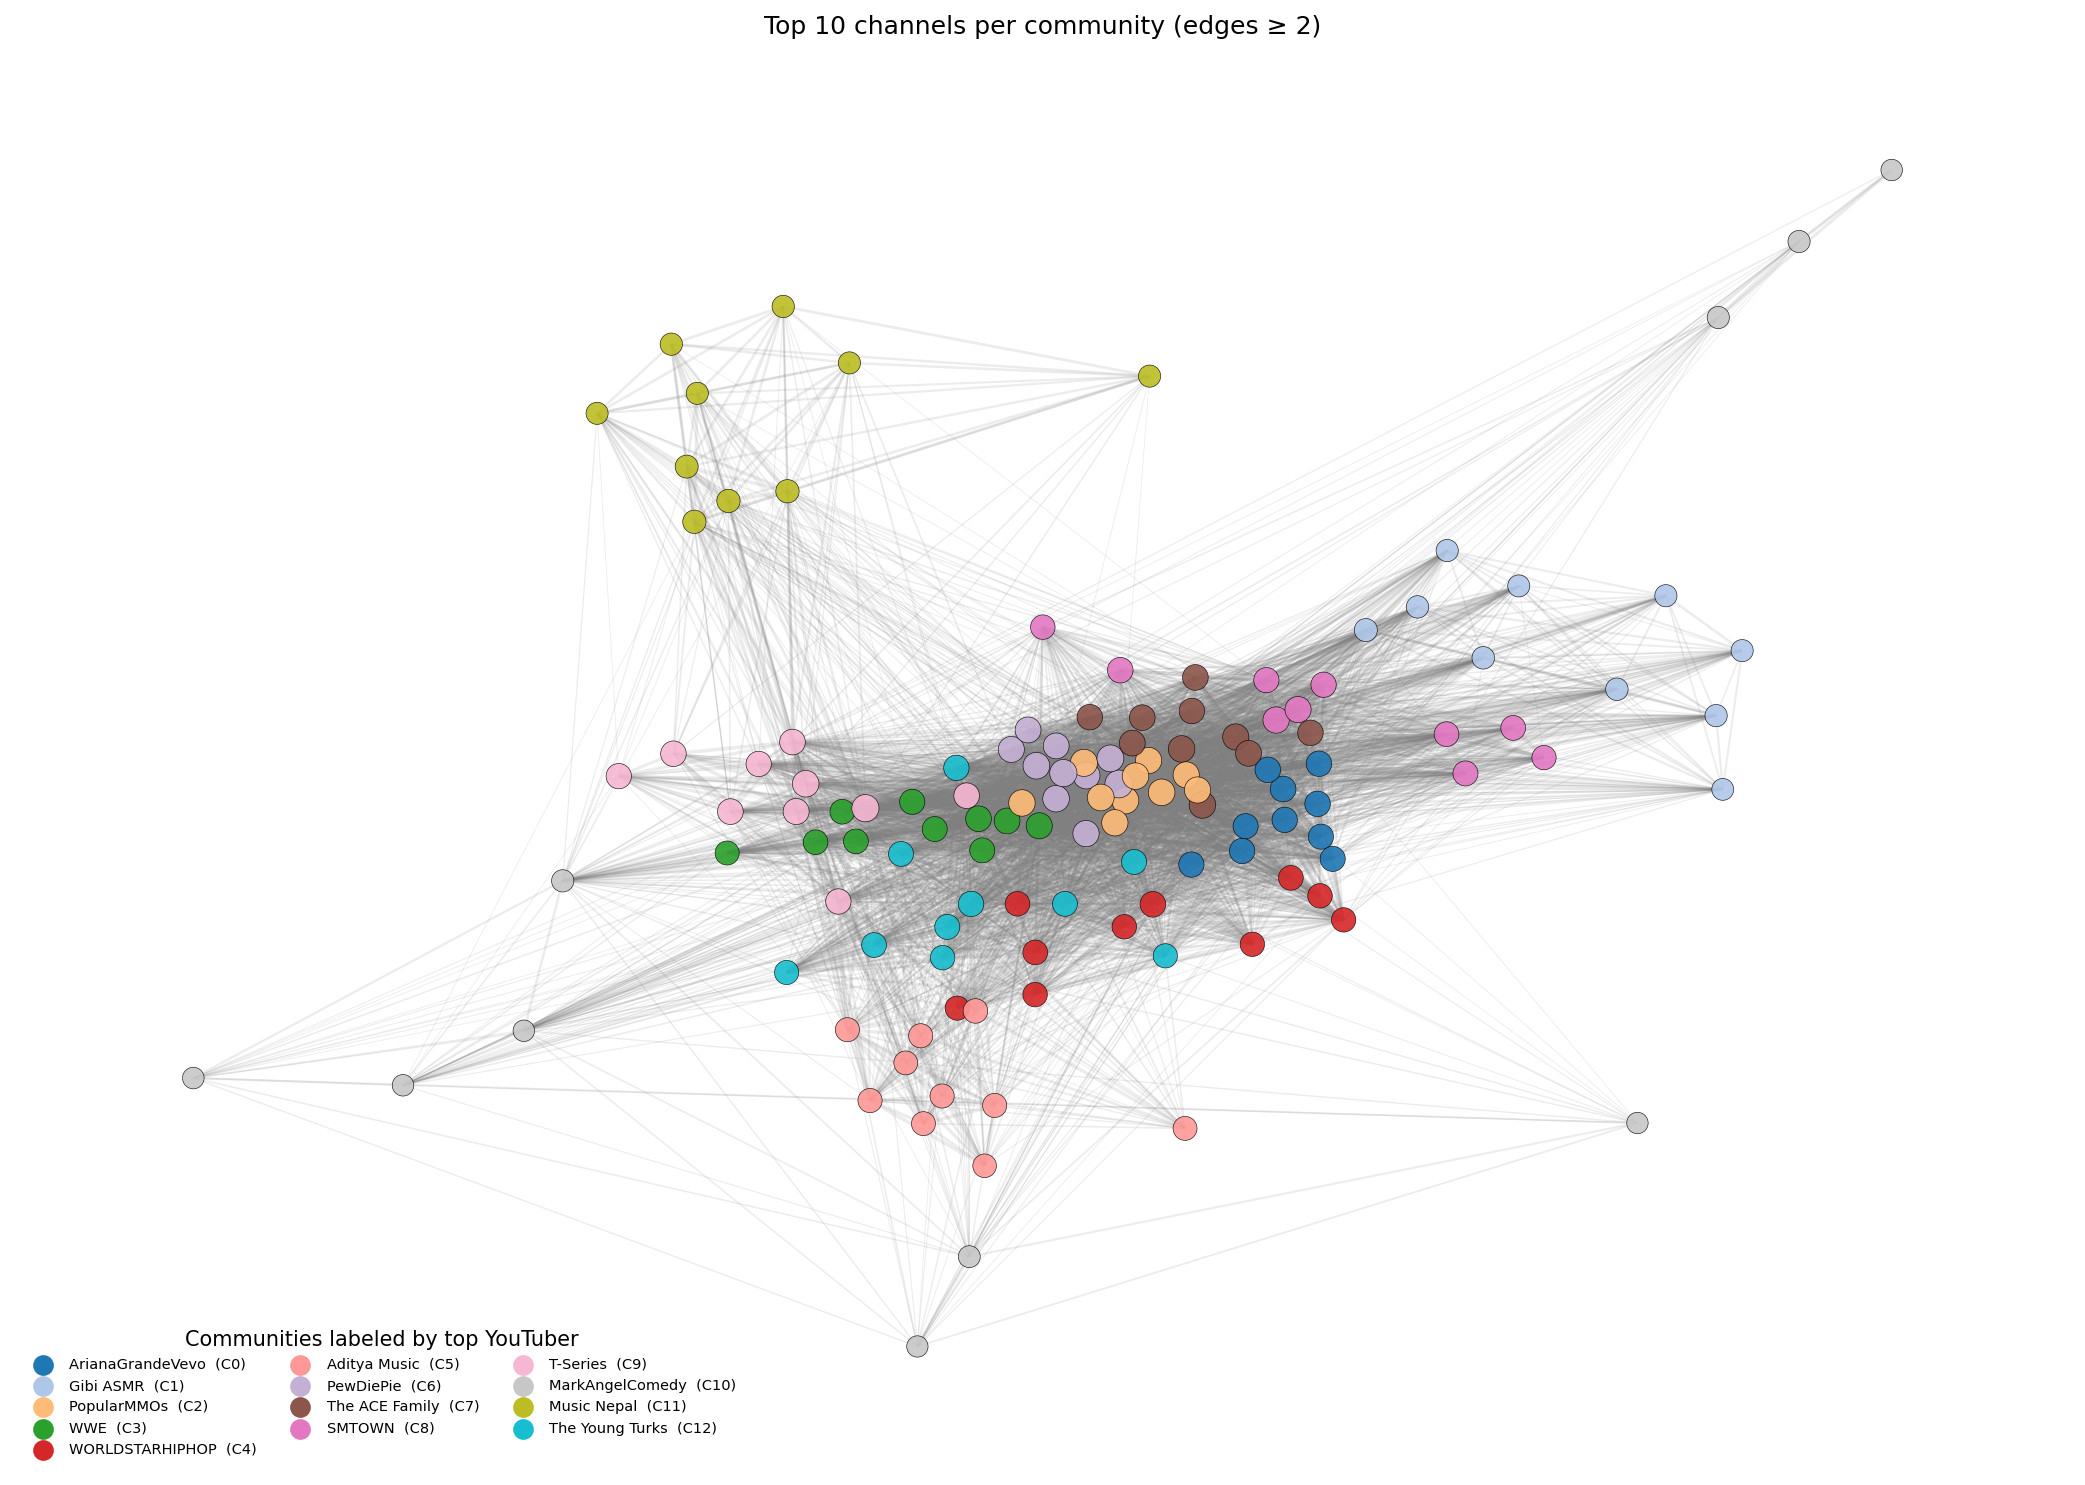

In [9]:
model_analyzer.visualize_network(
    LCC, 
    communities, 
    node_df, 
    viz_out_path=VIZ_OUT_PATH
)

## 6. Tracking audience movement and sniffing out echo chambers

We viewers as they hop between communities and flag the neighborhoods that trap them inside. We combine outward flow, conductance, and destination diversity to separate open boulevards from sealed echo rooms.

### 6.1 Who is talking to whom? (flows + metrics)

Question: are these communities busy train stations or dead-end cul-de-sacs? We collapse channel-to-channel edges into community-level flows with normalized weights, then compute:
- external share: how much strength leaks outside the community
- conductance: how easy it is to cut the group off
- destination diversity: entropy/Gini of where viewers head next

This builds the case file we will interrogate in the next steps.

In [ ]:
def gini(arr):
    # Simple Gini helper for a 1D array
    arr = np.asarray(arr, dtype=float)
    if arr.size == 0 or np.allclose(arr.sum(), 0):
        return 0.0
    arr = np.sort(arr)
    n = arr.size
    cumx = np.cumsum(arr)
    return (n + 1 - 2 * (cumx / cumx[-1]).sum()) / n

# Map each channel to its community for quick lookups
channel_to_comm = node_df.set_index("channel_id")['community']

# Aggregate channel→channel edges up to community→community level
edges_comm = (
    edges_normalized[["src", "dst", "weight", "weight_raw"]]
    .assign(
        src_comm=lambda df: df["src"].map(channel_to_comm),
        dst_comm=lambda df: df["dst"].map(channel_to_comm),
    )
    .dropna(subset=["src_comm", "dst_comm"])
    .astype({"src_comm": int, "dst_comm": int})
)

# Flag cross-community edges for later cuts
edges_comm["is_cross"] = edges_comm["src_comm"] != edges_comm["dst_comm"]

# Build community-level flow matrices (normalized + raw)
communities_sorted = sorted(node_df["community"].unique())
pair_strength = edges_comm.groupby(["src_comm", "dst_comm"])[["weight", "weight_raw"]].sum().reset_index()
flow_norm = pd.DataFrame(0.0, index=communities_sorted, columns=communities_sorted)
flow_raw = pd.DataFrame(0.0, index=communities_sorted, columns=communities_sorted)
for _, row in pair_strength.iterrows():
    a, b, w_norm, w_raw = int(row.src_comm), int(row.dst_comm), row.weight, row.weight_raw
    flow_norm.loc[a, b] += w_norm
    flow_raw .loc[a, b] += w_raw

# Remove self-loops to focus on outbound shares
flow_norm_no_diag = flow_norm.copy()
np.fill_diagonal(flow_norm_no_diag.values, 0)
flow_share = flow_norm_no_diag.div(flow_norm_no_diag.sum(axis=1), axis=0).fillna(0)

# External share (cut/volume) using normalized weights
total_strength = (
    edges_comm.groupby("src_comm")["weight"].sum()
    .add(edges_comm.groupby("dst_comm")["weight"].sum(), fill_value=0)
)
cut_cross = edges_comm[edges_comm["is_cross"]].groupby(["src_comm", "dst_comm"])['weight'].sum()
cut_per_comm = cut_cross.groupby(level=0).sum().add(cut_cross.groupby(level=1).sum(), fill_value=0)
external_share = (cut_per_comm / total_strength).fillna(0)

# Diversity of destinations (entropy/Gini) + top destination share
mobility_rows = []
for cid in communities_sorted:
    row = flow_share.loc[cid]
    dests = row[row > 0]
    if dests.empty:
        entropy = 0.0
        top_share = 0.0
        gini_out = 0.0
    else:
        p = dests / dests.sum()
        entropy = -np.sum(p * np.log2(p))
        top_share = p.max()
        gini_out = gini(p)
    mobility_rows.append({
        "community": cid,
        "external_share": float(external_share.get(cid, 0)),
        "entropy_out": float(entropy),
        "gini_out": float(gini_out),
        "top_dest_share": float(top_share),
    })

# Most common category per community (ties broken by mode)
mode_category = node_df.groupby("community")["category_cc"].agg(
    lambda s: s.mode().iat[0] if not s.mode().empty else "Unknown"
)

mobility_df = pd.DataFrame(mobility_rows).merge(
    comm_summary[["community", "n_nodes", "avg_degree"]], on="community", how="left"
).merge(mode_category.rename("top_category"), on="community", how="left")

# Rank communities from most closed to most open
mobility_df = mobility_df.sort_values(["external_share", "entropy_out"])
mobility_df.head(10)




,community,external_share,entropy_out,gini_out,top_dest_share,n_nodes,avg_degree,top_category
13,13,0.025646,-0.000000,0.000000,1.000000,2,1.500000,Education
9,9,0.109300,3.000960,0.482606,0.228486,4216,175.491461,Entertainment
11,11,0.124645,1.827194,0.720656,0.672392,130,102.438462,Entertainment
5,5,0.181613,1.732685,0.765959,0.683400,478,124.546025,Entertainment
10,10,0.295397,2.887479,0.526585,0.240849,170,70.388235,Music
8,8,0.327343,2.751503,0.565532,0.282186,871,170.182549,Entertainment
7,7,0.351428,2.780215,0.554056,0.242071,2349,182.364410,Howto & Style
6,6,0.381454,2.566851,0.622855,0.313308,3505,289.210271,Gaming
2,2,0.421064,2.725501,0.578969,0.343262,3448,255.889791,Entertainment
12,12,0.434992,2.811137,0.550029,0.292159,3264,136.672181,Education



### 6.2 Where does the audience go?

We now chase the biggest leaps: for each community, who captures most of its outgoing audience? This is our first clue about alliances versus isolation before we sketch the chord map.


In [ ]:
import seaborn as sns

# Find each community's top destinations (by share of outgoing flow)
top_partner_rows = []
for cid in communities_sorted:
    row = flow_share.loc[cid]
    if row.sum() == 0:
        continue  # no outbound flow to rank
    top_vals = row.sort_values(ascending=False).head(3)
    top_partner_rows.append({
        "community": cid,
        "top_partner": int(top_vals.index[0]),
        "share_to_top": float(top_vals.iloc[0]),
        "second_partner": int(top_vals.index[1]) if len(top_vals) > 1 else None,
        "share_to_second": float(top_vals.iloc[1]) if len(top_vals) > 1 else None,
    })

# Rank by strongest dependency on a single partner
top_partner_df = pd.DataFrame(top_partner_rows).sort_values("share_to_top", ascending=False)
display(top_partner_df.head(10))


,community,top_partner,share_to_top,second_partner,share_to_second
13,13,9,1.000000,0,0.000000
5,5,9,0.683400,12,0.099613
11,11,9,0.672392,0,0.086154
2,2,6,0.343262,0,0.170093
6,6,2,0.313308,0,0.225156
12,12,6,0.292159,0,0.204925
8,8,0,0.282186,2,0.196456
3,3,6,0.273130,2,0.199526
0,0,6,0.253341,12,0.180287
7,7,2,0.242071,0,0.211872


**Quick check:** The `top_partner_df` table surfaces, for each community, the destination that captures most of its outgoing flow. High `share_to_top` values mean heavy dependence on a single neighbor; a big gap to `share_to_second` points to a one-way corridor worth noting before we draw the chords.


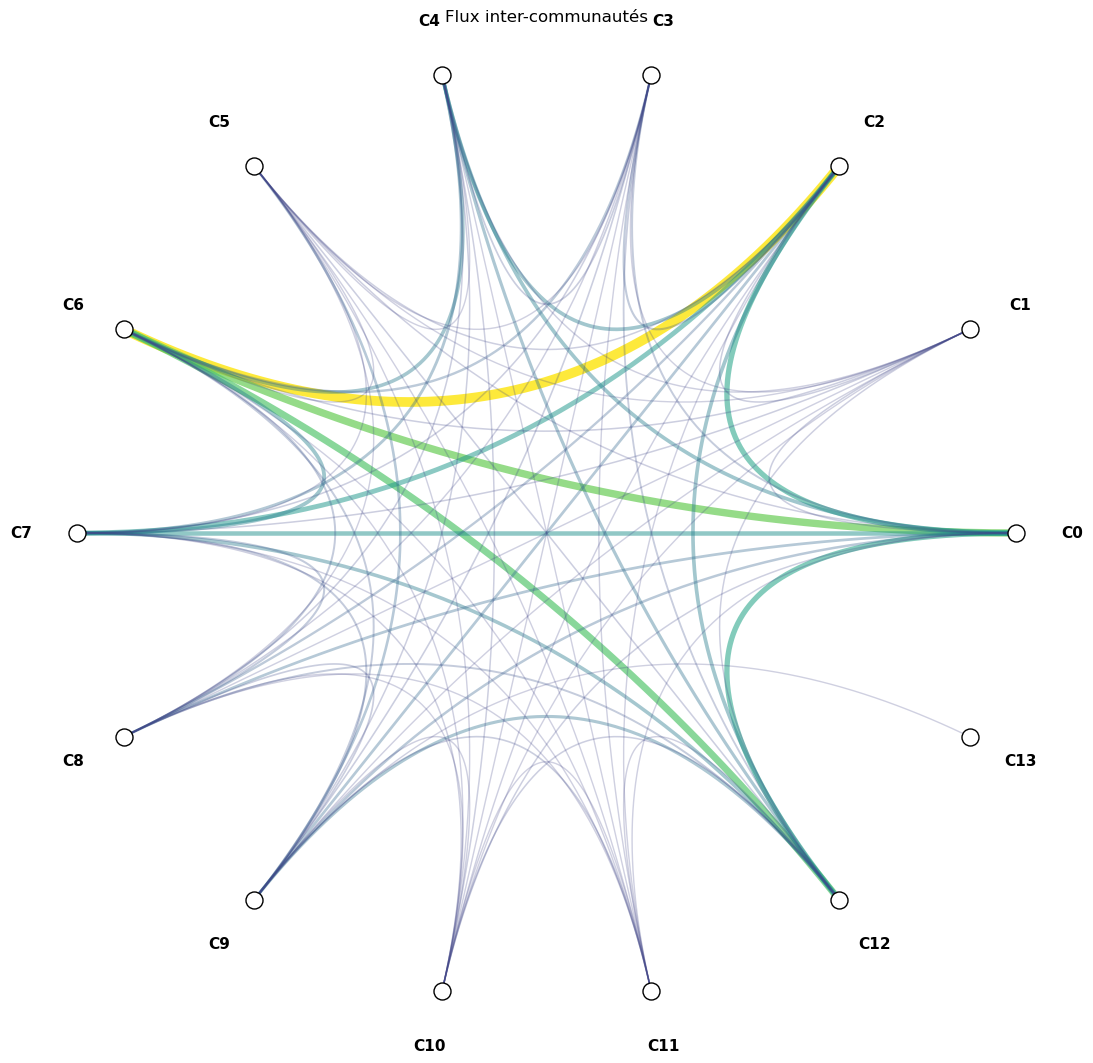

,c1,c2,weight
25,2,6,19889.223305
5,0,6,14306.712811
61,6,12,13049.150661
11,0,12,9420.897931
1,0,2,9409.580161
26,2,7,8235.831481
6,0,7,7429.888835
56,6,7,5764.775148
3,0,4,5540.365017
23,2,4,5495.322621


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Symmetrize flows (ignore direction) and keep the top 100 strongest links
flows = pair_strength.copy()
flows = flows[flows["src_comm"] != flows["dst_comm"]]
flows["a"] = flows[["src_comm", "dst_comm"]].min(axis=1)
flows["b"] = flows[["src_comm", "dst_comm"]].max(axis=1)
flows = flows.groupby(["a", "b"], as_index=False)["weight"].sum()
flows = flows.rename(columns={"a": "c1", "b": "c2"})
flows = flows.sort_values("weight", ascending=False).head(100)

# Place communities on a circle for the chord layout
order = sorted(communities_sorted)
theta = np.linspace(0, 2*np.pi, len(order), endpoint=False)
coords = {c: (np.cos(t), np.sin(t)) for c, t in zip(order, theta)}

# Style arcs by weight (thicker/darker = stronger flow)
w = flows["weight"]
w_norm = (w - w.min()) / (w.max() - w.min() + 1e-9)
widths = 1.0 + 6 * w_norm
colors = plt.cm.viridis(0.2 + 0.8 * w_norm)
alphas = 0.25 + 0.65 * w_norm

fig, ax = plt.subplots(figsize=(11, 11))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

# Draw quadratic arcs via the center to connect pairs
for (c1, c2, weight), lw, col, a in zip(flows[["c1", "c2", "weight"]].itertuples(index=False, name=None), widths, colors, alphas):
    x0, y0 = coords[c1]
    x1, y1 = coords[c2]
    ctrl = np.array([0, 0])
    t = np.linspace(0, 1, 150)
    curve = (1 - t)[:, None]**2 * np.array([x0, y0]) + 2*(1 - t)[:, None]*t[:, None]*ctrl + t[:, None]**2 * np.array([x1, y1])
    ax.plot(curve[:,0], curve[:,1], color=col, alpha=a, linewidth=lw, solid_capstyle='round')

# Draw community nodes
for c in order:
    x, y = coords[c]
    ax.scatter(x, y, s=150, color="white", edgecolor="black", zorder=3)
    ax.text(x*1.12, y*1.12, f"C{c}", ha="center", va="center", fontsize=11, weight="bold")

ax.set_aspect('equal')
ax.axis('off')
plt.title("Flux inter-communautés", fontsize=12)
plt.tight_layout()
plt.savefig("reports/figures/community_chord_simple.png", dpi=150, bbox_inches="tight")
plt.show()

# Top undirected flows for interpretation
display(flows.sort_values("weight", ascending=False).head(10))


**Field observation:** The chord diagram saved to `community_chord_simple.png` sketches the strongest cross-community corridors. Thick bands point to highways of shared audience; the top-10 flow table beneath names the pairs. Repeated pairings hint at long-standing alliances.


### 6.3 Echo-chamber suspects

We stack three clues—low external share, low conductance, and low destination diversity—to flag communities that sound like closed rooms. The next plot shades the lowest external shares so we can see which neighborhoods keep voices inside.

Seuils: external_share <= 0.210, entropie <= 2.766
Communautés les plus fermées (tri multi-critères):


,community,external_share,entropy_out,gini_out,n_nodes,top_category
13,13,0.025646,-0.000000,0.000000,2,Education
11,11,0.124645,1.827194,0.720656,130,Entertainment
5,5,0.181613,1.732685,0.765959,478,Entertainment


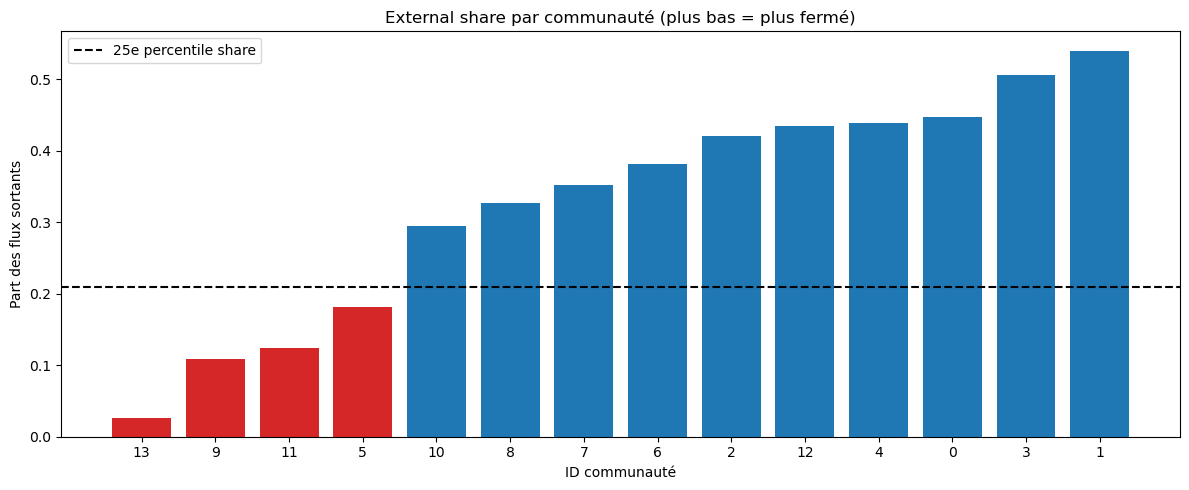

In [ ]:
# Thresholds: closed if external share and entropy both fall below med/25th
q_ext = mobility_df["external_share"].quantile(0.25)
q_ent = mobility_df["entropy_out"].quantile(0.50)

# Keep only low-outflow, low-diversity communities
# (few exits and concentrated destinations)
echo_candidates = mobility_df[
    (mobility_df["external_share"] <= q_ext)
    & (mobility_df["entropy_out"] <= q_ent)
].copy()

echo_candidates = echo_candidates.sort_values(["external_share", "entropy_out"])

print(f"Seuils: external_share <= {q_ext:.3f}, entropie <= {q_ent:.3f}")
print("Communautés les plus fermées (tri multi-critères):")
display(echo_candidates.head(10)[[
    "community", "external_share", "entropy_out", "gini_out", "n_nodes", "top_category"
]])

# Bar plot with suspects in red
plt.figure(figsize=(12, 5))
colors = ["#d62728" if es <= q_ext else "#1f77b4" for es in mobility_df["external_share"]]
plt.bar(mobility_df["community"].astype(str), mobility_df["external_share"], color=colors)
plt.axhline(q_ext, color="black", linestyle="--", label="25e percentile share")
plt.ylabel("Part des flux sortants")
plt.xlabel("ID communauté")
plt.title("External share par communauté (plus bas = plus fermé)")
plt.legend()
plt.tight_layout()
plt.savefig("reports/figures/echo_chamber_external_share.png", dpi=150, bbox_inches="tight")
plt.show()


**Interrogation:** The bar plot `echo_chamber_external_share.png` colors in red the commu
nities below the 25th percentile external share (≤0.210); paired with entropy ≤2.766, they are our tightest echo-chamber suspects. Check the `echo_candidates` table to see their size and dominant category before declaring the verdict.


### 6.4 Bridge channels and centrality

After naming the closed rooms, we search for the couriers who move viewers across walls. We rank channels by how much of their strength leaves their home community (cross_share), the raw cross-community force they exert, and their betweenness on the normalized graph.

In [ ]:
# Approx betweenness on the LCC (length = 1/weight so strong links are short)
G_bt = LCC.copy()
for u, v, d in G_bt.edges(data=True):
    w = d.get("weight", 1.0)
    d["length"] = 1 / (w + 1e-9)

# Sampled betweenness for speed (k=800 sources)
betweenness = nx.betweenness_centrality(G_bt, k=800, weight="length", seed=42)
node_df["betweenness"] = node_df["channel_id"].map(betweenness).fillna(0)

# Compute, for each channel, how much raw strength leaves its community
comm_map = node_df.set_index("channel_id")["community"].to_dict()
bridge_rows = []
for u in LCC.nodes():
    total_raw = 0.0
    cross_raw = 0.0
    for v, data in LCC[u].items():
        w = data.get("weight_raw", data.get("weight", 0))
        total_raw += w
        if comm_map.get(u) != comm_map.get(v):
            cross_raw += w
    cross_share = cross_raw / total_raw if total_raw > 0 else 0.0
    bridge_rows.append({
        "channel_id": u,
        "name": LCC.nodes[u].get("name_cc", u),
        "community": comm_map.get(u),
        "total_strength": total_raw,
        "cross_strength": cross_raw,
        "cross_share": cross_share,
        "degree": LCC.degree(u),
        "betweenness": betweenness.get(u, 0.0)
    })

bridge_df = pd.DataFrame(bridge_rows)
bridge_df = bridge_df.sort_values(["cross_share", "betweenness", "cross_strength"], ascending=[False, False, False])

# Bridges = channels with majority of strength outside and strong cross volume
bridge_top = bridge_df[(bridge_df["cross_share"] >= 0.5) & (bridge_df["cross_strength"] > 1000)]

print("Top canaux ponts (part vers d’autres communautés + betweenness):")
display(bridge_top.head(15)[[
    "name", "community", "cross_share", "cross_strength", "betweenness", "degree"
]])


Top canaux ponts (part vers d’autres communautés + betweenness):


,name,community,cross_share,cross_strength,betweenness,degree
1030,The Rock,12,0.900892,1818.0,1.401380e-05,299
9720,Bobby Duke Arts,7,0.898892,2596.0,3.952610e-06,409
15868,Humza Productions,4,0.896991,2534.0,2.771960e-06,341
5031,ASMRTheChew,1,0.887523,3322.0,3.767812e-05,445
48,DroidCheat,3,0.886249,1940.0,2.633362e-05,328
2799,pigmie,12,0.885294,1505.0,2.433165e-05,274
2701,Clifford Owusu,10,0.882521,1540.0,6.904234e-05,254
5680,Prince Ea,12,0.879200,5233.0,7.699889e-07,750
10986,Barry Lewis,12,0.878022,2433.0,1.827440e-05,394
2514,Skunky,4,0.877928,1237.0,3.772946e-05,180


**Bridge suspects:** The list of `bridge_top` channels mixes high cross_share (≥0.5) with strong betweenness. These are the couriers moving viewers across communities—prime suspects when explaining why two communities stay linked.


In [ ]:

import seaborn as sns
from ipywidgets import interact, widgets

bridge_top_cat = bridge_top.merge(node_df[["channel_id", "category_cc"]], on="channel_id", how="left")

# Top channels per community (sorted by cross reach, then betweenness, then force)
top_channels = (
    bridge_df
    .merge(node_df[["channel_id", "category_cc"]], on="channel_id", how="left")
    .sort_values(["community", "cross_share", "betweenness", "cross_strength"],
                 ascending=[True, False, False, False])
    .groupby("community")
    .head(10)
)
print("Top bridge channels per community (max 10):")
display(top_channels[[
    "community", "name", "category_cc", "cross_share", "cross_strength", "betweenness", "degree"
]])

# Aggregate bridge categories per community
agg = (
    bridge_top_cat
    .groupby(["community", "category_cc"])
    .agg(
        n_channels=("channel_id", "count"),
        cross_strength=("cross_strength", "sum"),
        avg_cross_share=("cross_share", "mean"),
    )
    .reset_index()
)
agg["share_strength"] = agg.groupby("community")["cross_strength"].transform(
    lambda s: s / s.sum()
)
print("Bridge categories per community:")
display(agg.head(20))



Top bridge channels per community (max 10):


,community,name,category_cc,cross_share,cross_strength,betweenness,degree
137,0,IMI DANCE STUDIO,Music,0.882353,30.0,6.673237e-07,8
157,0,Wheres Rucka,Comedy,0.876289,340.0,1.118024e-04,68
164,0,Pingu Official YouTu...,Entertainment,0.875000,28.0,5.903248e-06,7
180,0,Brandon Westenberg,Entertainment,0.870370,47.0,3.249353e-05,10
187,0,FOX5 Las Vegas,News & Politics,0.868421,198.0,4.368404e-05,40
...,...,...,...,...,...,...,...
41,12,Mary's Test Kitchen,Howto & Style,0.923077,48.0,1.166790e-04,10
42,12,Infectant,Gaming,0.923077,96.0,6.621905e-06,19
44,12,Atomic Shrimp,Howto & Style,0.920792,93.0,2.720627e-05,16
8204,13,Kids and Toys,Entertainment,0.500000,4.0,4.106608e-05,2


Bridge categories per community:


,community,category_cc,n_channels,cross_strength,avg_cross_share,share_strength
0,0,Comedy,15,96085.0,0.671809,0.060183
1,0,Education,1,1390.0,0.571311,0.000871
2,0,Entertainment,102,552684.0,0.633772,0.346177
3,0,Film and Animation,26,110611.0,0.641109,0.069282
4,0,Gaming,17,92989.0,0.600279,0.058244
5,0,Howto & Style,3,10319.0,0.647051,0.006463
6,0,Music,121,649783.0,0.580504,0.406996
7,0,People & Blogs,11,24855.0,0.639973,0.015568
8,0,Pets & Animals,3,10219.0,0.682788,0.006401
9,0,Science & Technology,6,13048.0,0.671739,0.008173


**Paper trail:** `top_channels` per community lists the ambassadors. Compare cross_strength (volume of cross-traffic) with cross_share (how concentrated their audience is outside). A modest share but huge strength signals a heavyweight that still reaches far beyond its base.


In [38]:

# Interactive bar: inspect top bridge channels per community
communities = sorted(top_channels["community"].unique())
palette = sns.color_palette("tab20", len(communities))
comm_color = {c: palette[i % len(palette)] for i, c in enumerate(communities)}

@interact(comm=widgets.Dropdown(options=communities, description="Community"))
def plot_top_channels_by_comm(comm):
    # Sort by cross strength to surface the biggest movers first
    data = top_channels[top_channels["community"] == comm].sort_values("cross_strength", ascending=False)
    if data.empty:
        print("No bridge channels for this community.")
        return
    plt.figure(figsize=(9, max(4, 0.4 * len(data))))
    sns.barplot(
        data=data,
        y="name",
        x="cross_strength",
        color=comm_color.get(comm, "#1f77b4")
    )
    for i, row in data.reset_index().iterrows():
        plt.text(row["cross_strength"] * 1.01, i, f"share {row['cross_share']:.2f}", va="center", fontsize=7)
    plt.xlabel("Cross strength (raw weight)")
    plt.ylabel("Channel")
    plt.title(f"Top bridge channels — community {comm}")
    plt.tight_layout()
    plt.show()


interactive(children=(Dropdown(description='Community', options=(np.int64(0), np.int64(1), np.int64(2), np.int…

**Interactive follow-up:** Use the dropdown to inspect each community. Focus on bars with high cross_strength and note when a bridge comes from an unexpected category that's a storyline worth narrating.


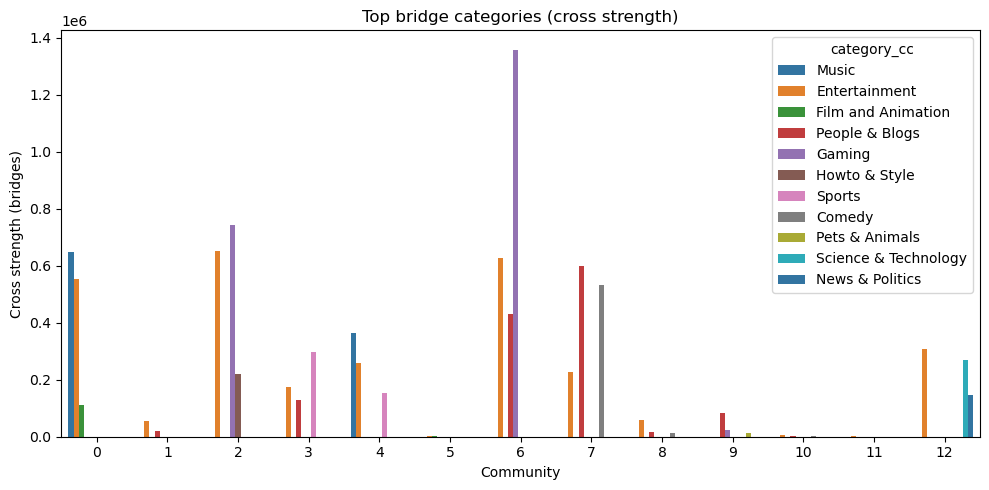

In [ ]:

# Grouped bars: top 3 bridge categories per community
cat_top3 = (
    agg.sort_values(["community", "cross_strength"], ascending=[True, False])
       .groupby("community")
       .head(3)
)

# Highest-volume bridge categories per community (top 3 each)
plt.figure(figsize=(10, 5))
sns.barplot(
    data=cat_top3,
    x="community",
    y="cross_strength",
    hue=cat_col,
    palette="tab10"
)
plt.ylabel("Cross strength (bridges)")
plt.xlabel("Community")
plt.title("Top bridge categories (cross strength)")
plt.tight_layout()
plt.savefig("reports/figures/bridge_categories_top3.png", dpi=150, bbox_inches="tight")
plt.show()


**Category pattern:** The grouped bars in `bridge_categories_top3.png` show which content themes dominate the bridges for each community. When one hue dominates a community, it suggests a single genre is doing most of the outreach.


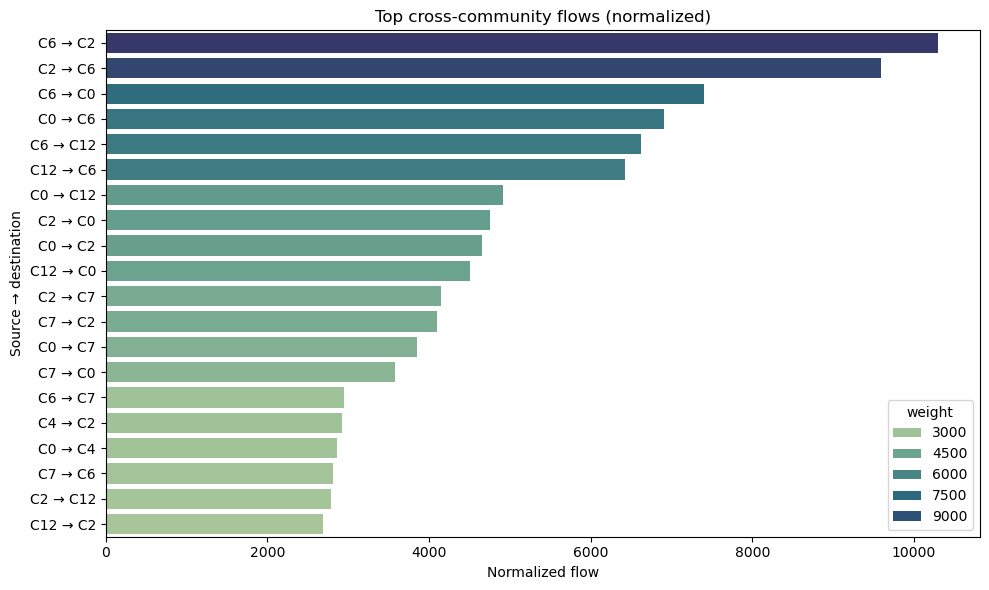

In [ ]:

# Alternative view: rank the strongest normalized cross-community flows
flow_long = flow_norm.stack().reset_index()
flow_long.columns = ["community_src", "community_dst", "weight"]
flow_long = flow_long[flow_long["community_src"] != flow_long["community_dst"]]
flow_long = flow_long[flow_long["weight"] > 0]
top_flows = flow_long.sort_values("weight", ascending=False).head(20)
plt.figure(figsize=(10, 6))
sns.barplot(
    data=top_flows,
    y=top_flows.apply(lambda r: f"C{int(r.community_src)} → C{int(r.community_dst)}", axis=1),
    x="weight",
    hue="weight",
    palette="crest"
)
plt.xlabel("Normalized flow")
plt.ylabel("Source → destination")
plt.title("Top cross-community flows (normalized)")
plt.tight_layout()
plt.savefig("reports/figures/bridge_community_topflows.png", dpi=150, bbox_inches="tight")
plt.show()


**Closing the case:** The normalized top flows chart (`bridge_community_topflows.png`) wraps up the story by ranking the strongest cross-community exchanges. Pair these corridors with the bridge channels above to explain *who* is pulling audiences across *which* divide. If the same community keeps reappearing as a destination, you've found the gravitational center of the network.
